# MIS 665 Final Project - Chakrapani Gajji (Section-II)

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Classifiers
#import decisiontreeclassifier
from sklearn import tree
from sklearn.tree import export_text
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#import logisticregression classifier
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
#import knn classifier
from sklearn.neighbors import KNeighborsClassifier

#regression packages
import sklearn.linear_model as lm

#for validating your classification model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

# feature selection
from sklearn.feature_selection import RFE
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.metrics import classification_report


# grid search
from sklearn.model_selection import GridSearchCV

import warnings
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore") 

pd.options.display.float_format = "{:,.2f}".format
np.set_printoptions(suppress=True, formatter={'float_kind':'{:.2f}'.format})

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Load and Prepare Data

In [3]:
# Load dataset
data = pd.read_csv("cleaned_data.csv") # we are using the dataset we have cleaned and saved in the section 1

* **ispremier** : 0 if Insider and 1 if Premier(they have upgraded from Insider. This is
the binary value we are attempting to predict.)
* **age21plus** : 0 is false; 1 is true
* **age18to21** : 0 is false; 1 is true
* **age13to18** : 0 is false; 1 is true
* **gendercode** : 0 is female; 1 is male; 3 is Unknown
* **birthdate**
* **loyalty_email_offer** : 0 is false; 1 is true
 > Opted in to receive AMC Loyalty program email offers.
* **reward_email** : 0 is false; 1 is true
 > Opted in to receive emails.
* **reward_mobile** : 0 is false; 1 is true
 > Opted in to receive mobile notifications.
* **reward_sms** : 0 is false; 1 is true
 > Opted in to receive AM Stubs SMS messages.
* **theatr_mob_offer** : 0 is false; 1 is true
 > Opted in to receive mobile theatre-level mobile offers.
* **theatr_sms_offer** : 0 is false; 1 is true
 > Opted in to receive theatre-level SMS offers.
* **life_award_amt** : Amount of rewards in dollars that a member has earned.
* **life_spend_amt** : Amount of total spend by a member.
* **ol_fee_waive_amt** : Amount of dollars in online ticketing fees waived as a member.
* **est_inc_rng** : Axciom estimate of estimated income range for member.

  0 : Unknown

  1 : Less than $15,000

  2 : $15,000-$19,999

  3 : $20,000-$29,999

  4 : $30,000-$39,999

  5 : $40,000-$49,999

  6 : $50,000-$74,999

  7 : $75,000-$99,999

  8 : $100,000-$124,999

  9 : Greater than $124,999
* **est_home_val_rng** : Axcion estimated home market value range for member.

  0 : Unknown

  1 : $1,000-$24,999

  2 : $25,000-$49,999

  3 : $50,000-$74,999

  4 : $75,000-$99,999

  5 : $100,000-$124,999

  6 : $125,000-$149,999

  7 : $150,000-$174,999

  8 : $175,000-$199,999

  9 : $200,000-$224,999

  10 : $225,000-$249,999

  11 : $250,000-$274,999

  12 : $275,000-$299,999

  13 : $300,000-$349,999

  14 : $349,000-$399,999

  15 : $400,000-$449,999

  16 : $450,000-$499,999

  17 : $500,000-$749,999

  18 : $750,000-$999,999

  19 : $1,000,000 plus

* **child_pres** : 0 is false; 1 is true; 3 is Unknown
 > Has children present in household.
* **freq_theatre** : 0 is false; 1 is true
 > Has a most frequently visited theatre selected through the site or by another means.
* **ticket_qty** : Number of tickets sold to this member.
* **ticket_bal** : Total US dollar value of tickets sold to this member.
* **concqtysum** : Total number of concession items purchased by this member.
* **concloydisc** : Total amount of loyalty discount received by this member (minus value in USD).
* **conc_bal** : Total US dollar value of concessions sold to this member.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46332 entries, 0 to 46331
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ispremier            46332 non-null  int64  
 1   age21plus            46332 non-null  int64  
 2   age18to21            46332 non-null  int64  
 3   age13to18            46332 non-null  int64  
 4   gendercode           46332 non-null  int64  
 5   loyalty_email_offer  46332 non-null  int64  
 6   reward_email         46332 non-null  int64  
 7   reward_mobile        46332 non-null  int64  
 8   reward_sms           46332 non-null  int64  
 9   theatr_mob_offer     46332 non-null  float64
 10  theatr_sms_offer     46332 non-null  int64  
 11  life_award_amt       46332 non-null  float64
 12  life_spend_amt       46332 non-null  float64
 13  ol_fee_waive_amt     46332 non-null  float64
 14  est_inc_rng          46332 non-null  int64  
 15  est_home_val_rng     46332 non-null 

In [5]:
# How likely someone be a premier member?

data['ispremier'].value_counts() / len(data)

ispremier
0   0.88
1   0.12
Name: count, dtype: float64

There is 12% chance of a randomly picked customer to be a premier member, which is very low.

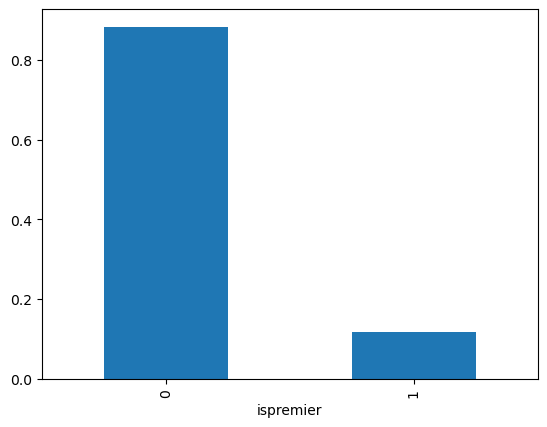

In [6]:
(data['ispremier'].value_counts() / len(data)).plot(kind='bar')
plt.show();

# Part I: Classification

## 1. The goal is to build a classification model to predict who is likely to convert to Premier using the algorithms (DT, LR, RF)

### a. Full-grown decision tree & simple decision tree

In [7]:
categorical_variables = ['ispremier',
                         'age21plus',
                         'loyalty_email_offer',
                         'theatr_mob_offer',
                         'theatr_sms_offer',
                         'reward_email',
                         'reward_mobile',
                         'child_pres',
                         'freq_theatre',
                         'est_inc_rng',
                         'est_home_val_rng',
                         'reward_sms',
                         'gendercode',
                         'age13to18',
                         'age18to21']

In [8]:
# convert categorical variables to dummy variables

df_dummies =  pd.get_dummies(data, columns=categorical_variables)
df_dummies.head(2)

,life_award_amt,life_spend_amt,ol_fee_waive_amt,ticket_qty,ticket_bal,concqtysum,concloydisc,conc_bal,unk_inc,unk_home,...,est_home_val_rng_19,reward_sms_0,reward_sms_1,gendercode_0,gendercode_1,gendercode_3,age13to18_0,age13to18_1,age18to21_0,age18to21_1
0,0.00,0.00,0.00,2,29.58,0,0.00,0.00,1,1,...,True,True,False,True,False,False,True,False,True,False
1,5.00,63.04,0.00,20,191.90,0,0.00,0.00,1,1,...,True,True,False,False,False,True,False,True,True,False


In [9]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46332 entries, 0 to 46331
Data columns (total 69 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   life_award_amt         46332 non-null  float64
 1   life_spend_amt         46332 non-null  float64
 2   ol_fee_waive_amt       46332 non-null  float64
 3   ticket_qty             46332 non-null  int64  
 4   ticket_bal             46332 non-null  float64
 5   concqtysum             46332 non-null  int64  
 6   concloydisc            46332 non-null  float64
 7   conc_bal               46332 non-null  float64
 8   unk_inc                46332 non-null  int64  
 9   unk_home               46332 non-null  int64  
 10  age                    46332 non-null  int64  
 11  ispremier_0            46332 non-null  bool   
 12  ispremier_1            46332 non-null  bool   
 13  age21plus_0            46332 non-null  bool   
 14  age21plus_1            46332 non-null  bool   
 15  lo

In [10]:
df_dummies.corr()

,life_award_amt,life_spend_amt,ol_fee_waive_amt,ticket_qty,ticket_bal,concqtysum,concloydisc,conc_bal,unk_inc,unk_home,...,est_home_val_rng_19,reward_sms_0,reward_sms_1,gendercode_0,gendercode_1,gendercode_3,age13to18_0,age13to18_1,age18to21_0,age18to21_1
life_award_amt,1.00,1.00,0.03,0.19,0.16,0.31,0.19,0.32,0.25,0.25,...,0.11,-0.02,0.02,0.00,0.03,-0.02,0.02,-0.02,0.04,-0.04
life_spend_amt,1.00,1.00,0.03,0.20,0.17,0.32,0.20,0.33,0.25,0.25,...,0.11,-0.02,0.02,0.00,0.03,-0.02,0.03,-0.03,0.04,-0.04
ol_fee_waive_amt,0.03,0.03,1.00,0.84,0.91,0.03,0.00,0.03,0.00,0.00,...,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.02,0.02
ticket_qty,0.19,0.20,0.84,1.00,0.97,0.26,0.16,0.27,0.09,0.10,...,0.03,0.00,-0.00,0.06,0.06,-0.09,0.04,-0.04,0.01,-0.01
ticket_bal,0.16,0.17,0.91,0.97,1.00,0.19,0.11,0.19,0.06,0.07,...,0.03,0.00,-0.00,0.04,0.05,-0.07,0.03,-0.03,0.00,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gendercode_3,-0.02,-0.02,0.00,-0.09,-0.07,-0.03,-0.10,-0.02,-0.23,-0.28,...,-0.03,-0.00,0.00,-0.75,-0.57,1.00,-0.04,0.04,-0.03,0.03
age13to18_0,0.02,0.03,0.00,0.04,0.03,0.04,0.03,0.04,0.06,0.05,...,0.00,-0.00,0.00,0.03,0.02,-0.04,1.00,-1.00,-0.05,0.05
age13to18_1,-0.02,-0.03,-0.00,-0.04,-0.03,-0.04,-0.03,-0.04,-0.06,-0.05,...,-0.00,0.00,-0.00,-0.03,-0.02,0.04,-1.00,1.00,0.05,-0.05
age18to21_0,0.04,0.04,-0.02,0.01,0.00,0.04,0.03,0.04,0.05,0.04,...,0.00,-0.00,0.00,0.03,0.01,-0.03,-0.05,0.05,1.00,-1.00


In [11]:
corr = pd.DataFrame(df_dummies.corr()['ispremier_1'].drop('ispremier_1'))
corr.sort_values(['ispremier_1'], ascending = False)

,ispremier_1
conc_bal,0.34
concloydisc,0.34
concqtysum,0.34
ticket_qty,0.26
life_spend_amt,0.22
...,...
child_pres_3,-0.11
est_inc_rng_0,-0.13
est_home_val_rng_0,-0.13
gendercode_3,-0.28


#### i) Visualize the Simple Decision Tree

In [12]:
# Define features (X) and target (y)
X = data.drop(columns=["ispremier"])
y = data["ispremier"]

In [13]:
y.shape, X.shape

((46332,), (46332, 25))

In [14]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(32432, 25) (13900, 25) (32432,) (13900,)


In [15]:
# Initialize DecisionTreeClassifier()
dt = DecisionTreeClassifier()

# Train a decision tree model
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [16]:
#Model evaluation
print(metrics.accuracy_score(y_test, dt.predict(X_test)))
print("--------------------------------------------------------")
print(metrics.confusion_matrix(y_test, dt.predict(X_test))) 
print("--------------------------------------------------------")
print(metrics.classification_report(y_test, dt.predict(X_test)))
print("--------------------------------------------------------")
print(metrics.roc_auc_score(y_test, dt.predict(X_test)))

0.9516546762589928
--------------------------------------------------------
[[11931   314]
 [  358  1297]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     12245
           1       0.81      0.78      0.79      1655

    accuracy                           0.95     13900
   macro avg       0.89      0.88      0.88     13900
weighted avg       0.95      0.95      0.95     13900

--------------------------------------------------------
0.87902134048178


The decision tree model is 88.1% accurate.

True Positive Rate (Sensitivity) = 1303/1655 = 0.78

False Positive Rate = 307/12245 = 0.025

True Negative Rate (Specificity) = 11938/12245

False Negative Rate = 352/1655

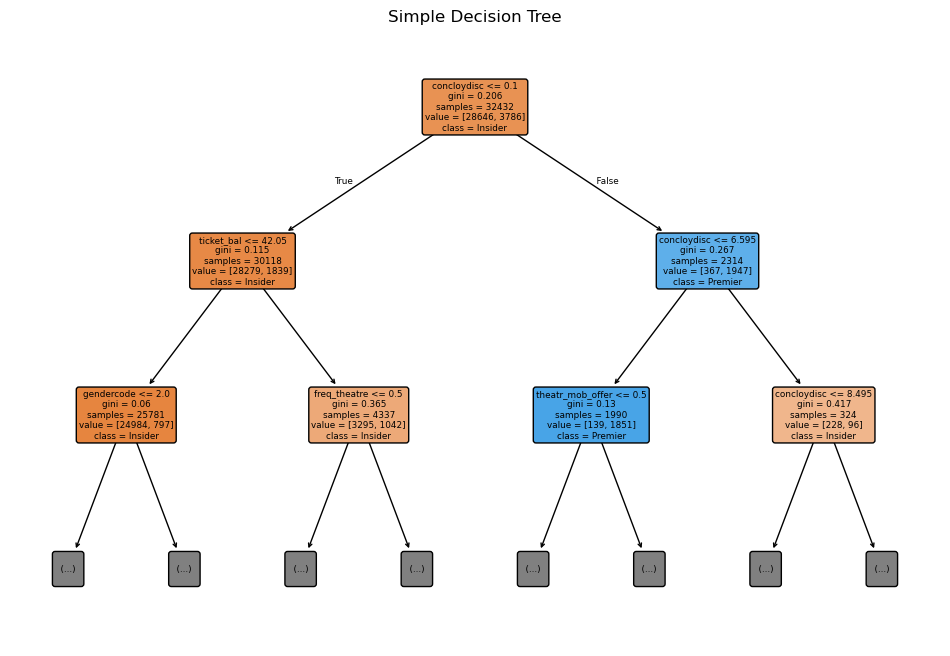

In [17]:
# Set up the plot size
plt.figure(figsize=(12, 8))

# Visualize the decision tree
plot_tree(dt, 
          feature_names=X.columns,  # Provide feature names
          class_names=["Insider", "Premier"],  # Adjust class names as appropriate
          filled=True, 
          rounded=True, 
          max_depth=2)  # Limit visualization to the first 3 levels for simplicity
          
plt.title("Simple Decision Tree")
plt.show()

#### ii) Most Important Variables from Simple Decision Tree

In [18]:
# Calculate feature importances using the trained decision tree model `dt`
importances = pd.DataFrame({
    "Feature": X.columns,  # Feature names
    "Importance": dt.feature_importances_  # Use the `dt` model for feature importance
}).sort_values(by="Importance", ascending=False)  # Sort by importance in descending order

# Display feature importance
print("Feature Importance:\n")
importances

Feature Importance:



,Feature,Importance
20,concloydisc,0.45
11,life_spend_amt,0.10
18,ticket_bal,0.10
16,freq_theatre,0.09
6,reward_mobile,0.05
24,age,0.04
17,ticket_qty,0.03
21,conc_bal,0.03
12,ol_fee_waive_amt,0.02
8,theatr_mob_offer,0.02


- The **Concession Loyalty Discount** plays the major role in deciding whether the customer would like to be a premier or an Insider member.

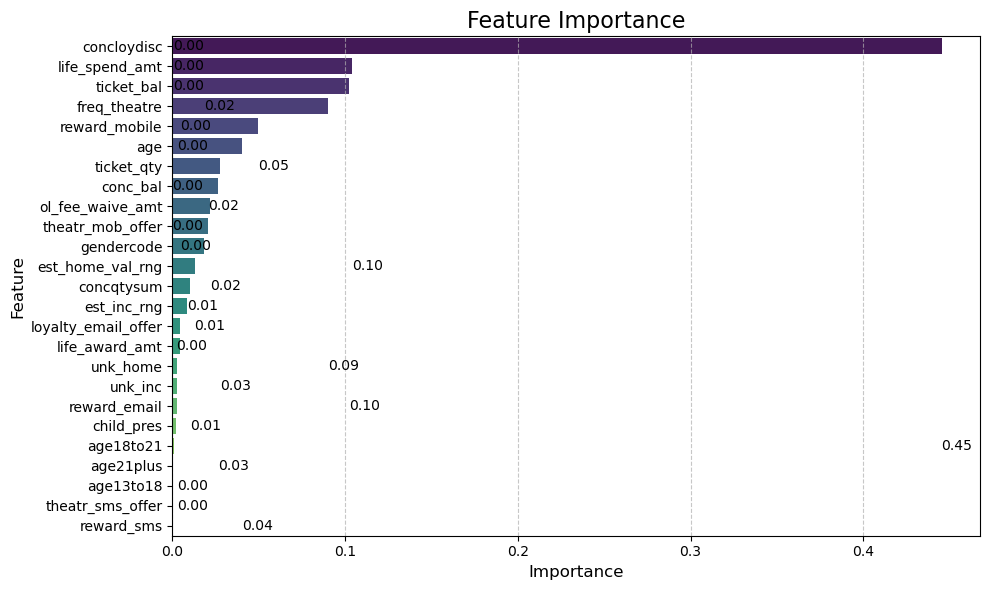

In [19]:
# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importances, palette="viridis")

# Annotate each bar with its importance value
for index, row in importances.iterrows():
    plt.text(row["Importance"], index, f"{row['Importance']:.2f}", va='center')

# Customize the plot
plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

#### iii) Decision Rules from Simple Decision Tree

In [20]:
from sklearn.tree import export_text

# Export a simplified text representation of the decision tree
text_representation = export_text(dt, 
                                   feature_names=list(X.columns), 
                                   max_depth=3)  # Restrict to 3 levels for simplicity
print(text_representation)

|--- concloydisc <= 0.10
|   |--- ticket_bal <= 42.05
|   |   |--- gendercode <= 2.00
|   |   |   |--- reward_mobile <= 0.50
|   |   |   |   |--- truncated branch of depth 21
|   |   |   |--- reward_mobile >  0.50
|   |   |   |   |--- truncated branch of depth 19
|   |   |--- gendercode >  2.00
|   |   |   |--- ticket_qty <= 2.50
|   |   |   |   |--- truncated branch of depth 25
|   |   |   |--- ticket_qty >  2.50
|   |   |   |   |--- truncated branch of depth 14
|   |--- ticket_bal >  42.05
|   |   |--- freq_theatre <= 0.50
|   |   |   |--- reward_mobile <= 0.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- reward_mobile >  0.50
|   |   |   |   |--- truncated branch of depth 16
|   |   |--- freq_theatre >  0.50
|   |   |   |--- ticket_bal <= 118.79
|   |   |   |   |--- truncated branch of depth 21
|   |   |   |--- ticket_bal >  118.79
|   |   |   |   |--- truncated branch of depth 11
|--- concloydisc >  0.10
|   |--- concloydisc <= 6.60
|   |   |--- theatr_mob_off

1. If loyalty discount is ≤ 0.10 and ticket balance ≤ 42.05, further decisions depend on gender and mobile reward engagement. 
2. If ticket balance > 42.05 and frequency of theater visits ≤ 0.50, reward mobile engagement determines the next decision.
3. If loyalty discount is between 0.10 and 6.60 and theater mobile offers ≤ 0.50, the total spending amount decides further classification.  
4. If loyalty discount is > 6.60 and ≤ 8.49, spending above 407.47 triggers a specific path.
5. If loyalty discount > 8.49 and ticket balance ≤ 17.11, follow the path for low spending and loyalty.

In [21]:
# deploy your model for real world
predictedY = dt.predict(X_test)

#combine the predicted Y value with the scoring dataset
predictedY = pd.DataFrame(predictedY, columns=['predicted Y'])
predictedY.value_counts()

predicted Y
0              12289
1               1611
Name: count, dtype: int64

In [22]:
# evaluate the decision tree model using 50-fold cross-validation
# initialize decision tree algorithm (without fitting)

scores = cross_val_score(DecisionTreeClassifier(), X, y, scoring='accuracy', cv=50)
print(scores)
print(scores.mean())

[0.91 0.94 0.93 0.87 0.91 0.92 0.91 0.91 0.91 0.92 0.90 0.95 0.96 0.97
 0.97 0.47 0.59 0.58 0.47 0.59 0.82 0.90 0.91 0.87 0.95 0.89 0.83 0.91
 0.83 0.86 0.87 0.73 0.97 0.93 0.97 0.96 0.96 0.94 0.97 0.96 0.96 0.97
 0.95 0.97 0.95 0.98 0.96 0.95 0.97 0.96]
0.8850765259167617


In [23]:
#The mean score and the 95% confidence interval of the score estimate are hence given by:
print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

Accuracy: 0.89 (+/- 0.25)


### b. Logistic Regression

In [24]:
# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [25]:
# print coefficients
coef = pd.DataFrame(list(zip(X.columns, np.transpose(logistic_model.coef_))), 
             columns=['X variables', 'coef']).sort_values('coef', ascending=False)

coef['coef'] = coef['coef'].str[0]
coef

,X variables,coef
8,theatr_mob_offer,0.75
6,reward_mobile,0.73
20,concloydisc,0.37
17,ticket_qty,0.15
10,life_award_amt,0.10
13,est_inc_rng,0.05
5,reward_email,0.03
18,ticket_bal,0.02
21,conc_bal,0.02
15,child_pres,0.02


In [26]:
#Model evaluation

print(metrics.accuracy_score(y_test, logistic_model.predict(X_test)))
print(metrics.confusion_matrix(y_test, logistic_model.predict(X_test)))
print(metrics.classification_report(y_test, logistic_model.predict(X_test)))
print(metrics.roc_auc_score(y_test, logistic_model.predict(X_test)))

0.9274820143884892
[[12040   205]
 [  803   852]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     12245
           1       0.81      0.51      0.63      1655

    accuracy                           0.93     13900
   macro avg       0.87      0.75      0.79     13900
weighted avg       0.92      0.93      0.92     13900

0.7490310491118516


In [27]:
# generate class probabilities
probs = logistic_model.predict_proba(X_test)
pd.DataFrame(probs, columns=['Insider', 'Premier']).head()

,Insider,Premier
0,0.97,0.03
1,0.92,0.08
2,0.99,0.01
3,0.99,0.01
4,0.56,0.44


In [28]:
# evaluate the logit model using 10-fold cross-validation

scores = cross_val_score(LogisticRegression(solver='lbfgs', max_iter=500), X, y, scoring='accuracy', cv=10)
print(scores)
print(scores.mean())

[0.91 0.88 0.92 0.88 0.93 0.95 0.93 0.91 0.92 0.90]
0.9134732806187358


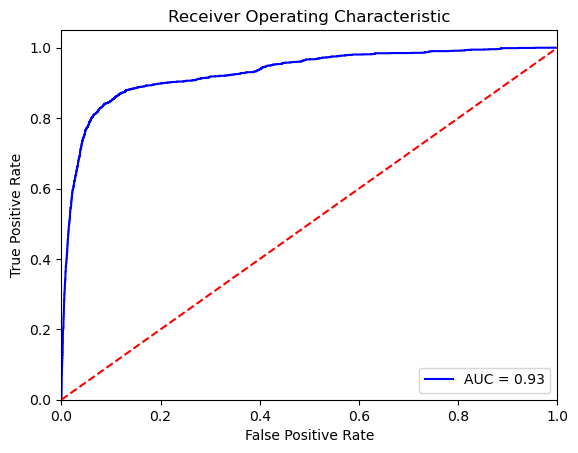

In [29]:
preds = logistic_model.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

### c. Random Forest

In [30]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators = 20, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, random_state=42)

In [31]:
# another method
pd.DataFrame(rf_model.feature_importances_, index = X.columns,
                                    columns=['importance']).sort_values('importance', ascending=False)

,importance
concloydisc,0.23
ticket_bal,0.12
ticket_qty,0.11
life_spend_amt,0.09
freq_theatre,0.08
conc_bal,0.06
age,0.05
gendercode,0.04
reward_mobile,0.04
concqtysum,0.04


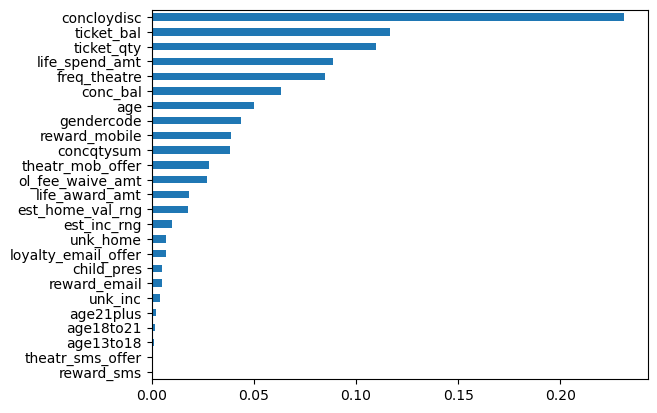

In [32]:
pd.DataFrame(rf_model.feature_importances_, index = X.columns, 
             columns=['importance']).sort_values('importance', ascending=True).plot(kind='barh', 
                                                                                     legend=None)
plt.show();

In [33]:
# generate evaluation metrics
print(metrics.accuracy_score(y_test, rf_model.predict(X_test))) #overall accuracy
print(metrics.confusion_matrix(y_test, rf_model.predict(X_test)))
print(metrics.classification_report(y_test, rf_model.predict(X_test)))
print(metrics.roc_auc_score(y_test, rf_model.predict(X_test)))

0.9659712230215828
[[12126   119]
 [  354  1301]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     12245
           1       0.92      0.79      0.85      1655

    accuracy                           0.97     13900
   macro avg       0.94      0.89      0.91     13900
weighted avg       0.97      0.97      0.96     13900

0.8881922333426677


The Random Forest Classifier model is 96.5% accurate.

True Positive Rate (Sensitivity) = 1301/1655 = 0.78

False Positive Rate = 119/12245 = 0.009

True Negative Rate (Specificity) = 12126/12245

False Negative Rate = 354/1655

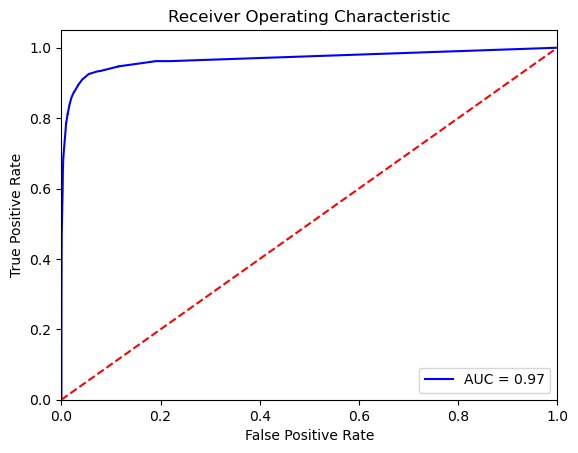

In [34]:
preds = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

### d. Classification with Feature Selection

In [35]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 5 features based on ANOVA F-test
selector = SelectKBest(f_classif, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train Random Forest with selected features
rf_model_fs = RandomForestClassifier(random_state=42)
rf_model_fs.fit(X_train_selected, y_train)

RandomForestClassifier(random_state=42)

In [36]:
# Import necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# Apply Logistic Regression with L1 Regularization (Lasso)
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Get feature importance (coefficients) after L1 regularization
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_[0]
})

In [38]:
# Select non-zero coefficient features (selected features)
selected_features = feature_importance[feature_importance["Coefficient"] != 0]
print("Selected Features:\n")
pd.DataFrame(selected_features)

Selected Features:



,Feature,Coefficient
0,age21plus,-0.50
1,age18to21,-0.52
2,age13to18,-0.48
3,gendercode,-0.80
4,loyalty_email_offer,-0.07
5,reward_email,0.02
6,reward_mobile,0.36
8,theatr_mob_offer,0.39
10,life_award_amt,2.65
11,life_spend_amt,-2.57


In [39]:
# Use only selected features for prediction
X_train_selected = X_train_scaled[:, selected_features.index]
X_test_selected = X_test_scaled[:, selected_features.index]

# Train a classification model using selected features
final_model = LogisticRegression(random_state=42)
final_model.fit(X_train_selected, y_train)

# Make predictions
y_pred = final_model.predict(X_test_selected)

In [40]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}\n")


Model Accuracy: 0.93



In [41]:
from sklearn.metrics import classification_report

# Generate classification report as a dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Print the DataFrame
print("Classification Report:\n")
report_df

Classification Report:



,precision,recall,f1-score,support
0,0.94,0.98,0.96,"12,245.00"
1,0.81,0.52,0.63,"1,655.00"
accuracy,0.93,0.93,0.93,0.93
macro avg,0.87,0.75,0.80,"13,900.00"
weighted avg,0.92,0.93,0.92,"13,900.00"


## 2. ROC Curve Comparison

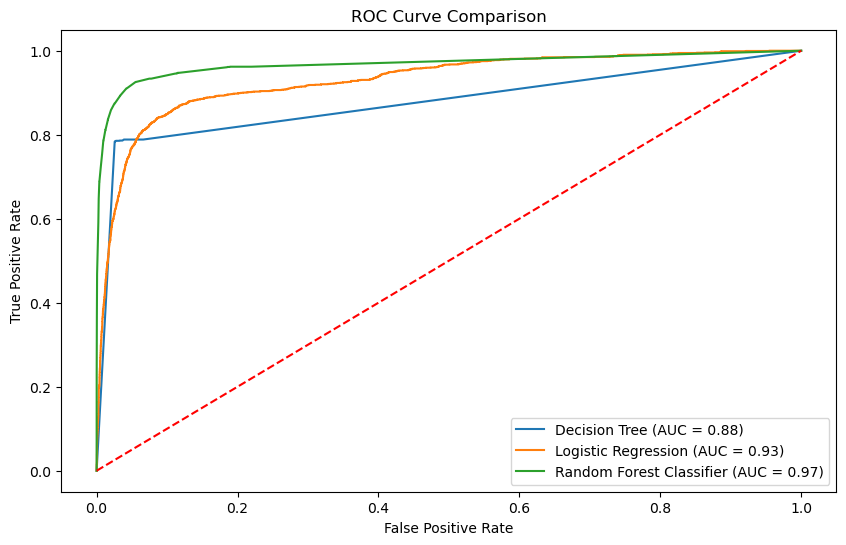

In [42]:
# Predictions and probabilities
y_pred_prob_dt = dt.predict_proba(X_test)[:, 1]
y_pred_prob_lr = logistic_model.predict_proba(X_test)[:, 1]
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

# Plot ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_dt, tpr_dt, label="Decision Tree (AUC = {:.2f})".format(roc_auc_score(y_test, y_pred_prob_dt)))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (AUC = {:.2f})".format(roc_auc_score(y_test, y_pred_prob_lr)))
plt.plot(fpr_rf, tpr_rf, label="Random Forest Classifier (AUC = {:.2f})".format(roc_auc_score(y_test, y_pred_prob_rf)))
plt.plot([0, 1], [0, 1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 3. Best Classification Model

In [43]:
# Compare models' performance
auc_dt = roc_auc_score(y_test, y_pred_prob_dt)
auc_lr = roc_auc_score(y_test, y_pred_prob_lr)
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)

best_model = max([(auc_dt, "Decision Tree"), (auc_lr, "Logistic Regression"), (auc_rf, "Random Forest")], key=lambda x: x[0])

print(f"Best Model: {best_model[1]}")

Best Model: Random Forest


### a) What is the model accuracy?

In [44]:
print(f"Accuracy: {best_model[0]:.2f}")

Accuracy: 0.97


### b) True positive rate? False positive rate?

In [45]:
cm = metrics.confusion_matrix(y_test, rf_model.predict(X_test))

# Extract values from the confusion matrix
TN = cm[0, 0]  # True Negatives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives
TP = cm[1, 1]  # True Positives

# Calculate True Positive Rate (TPR) and False Positive Rate (FPR)
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)

# Print the results
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

True Positive Rate (TPR): 0.79
False Positive Rate (FPR): 0.01


### c) What is ROC score?

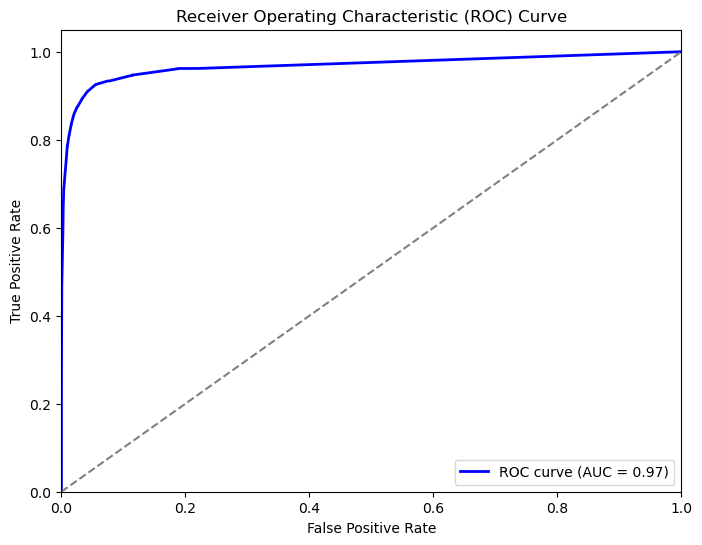

In [46]:
# Predict probabilities for the positive class
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probability of the positive class (class 1)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show();

# Part II: Regression

## 1. Remove Columns TICKET_QTY, FREQ_THEATRE, and ISPREMIER.

In [47]:
# Drop unnecessary columns
data_reg = data.drop(columns=["ticket_qty", "freq_theatre", "ispremier"], errors="ignore")

# Inspect the data
data_reg.head()

,age21plus,age18to21,age13to18,gendercode,loyalty_email_offer,reward_email,reward_mobile,reward_sms,theatr_mob_offer,theatr_sms_offer,...,est_inc_rng,est_home_val_rng,child_pres,ticket_bal,concqtysum,concloydisc,conc_bal,unk_inc,unk_home,age
0,0,0,0,0,1,1,0,0,0.00,0,...,8,19,0,29.58,0,0.00,0.00,1,1,8
1,0,0,1,3,1,1,1,0,1.00,0,...,8,19,3,191.90,0,0.00,0.00,1,1,23
2,1,0,0,0,1,1,0,0,0.00,0,...,8,19,1,192.84,1,8.49,0.00,1,1,71
3,1,0,0,0,0,0,0,0,0.00,0,...,8,19,1,0.00,1,0.00,0.00,1,1,62
4,1,0,0,0,0,0,0,0,0.00,0,...,8,19,3,101.20,0,0.00,0.00,1,1,59


## 2. Detect and Remove Abnormal ticket_bal

Visualize ticket_bal for Outliers

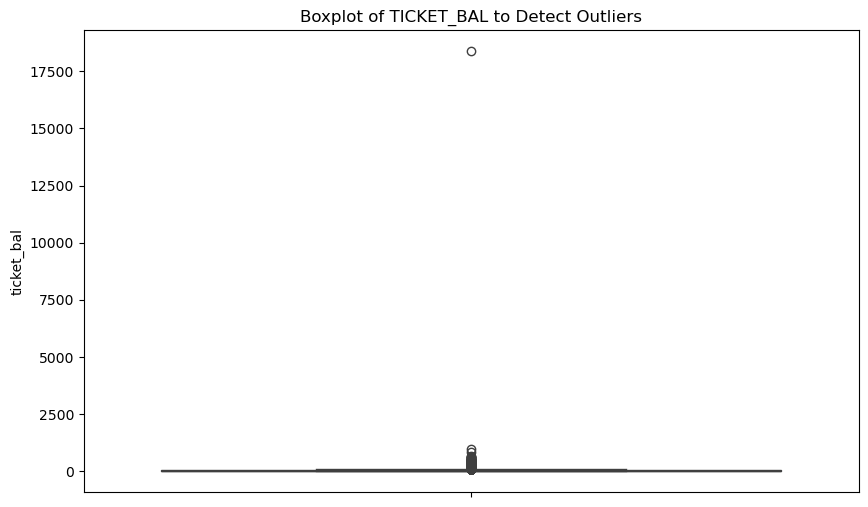

In [48]:
import seaborn as sns

# Visualize TICKET_BAL distribution to detect anomalies
plt.figure(figsize=(10, 6))
sns.boxplot(data_reg["ticket_bal"])
plt.title("Boxplot of TICKET_BAL to Detect Outliers")
plt.show()

Remove Rows with Abnormal TICKET_BAL

In [49]:
data_reg = data_reg[data_reg['ticket_bal'] < 1000]

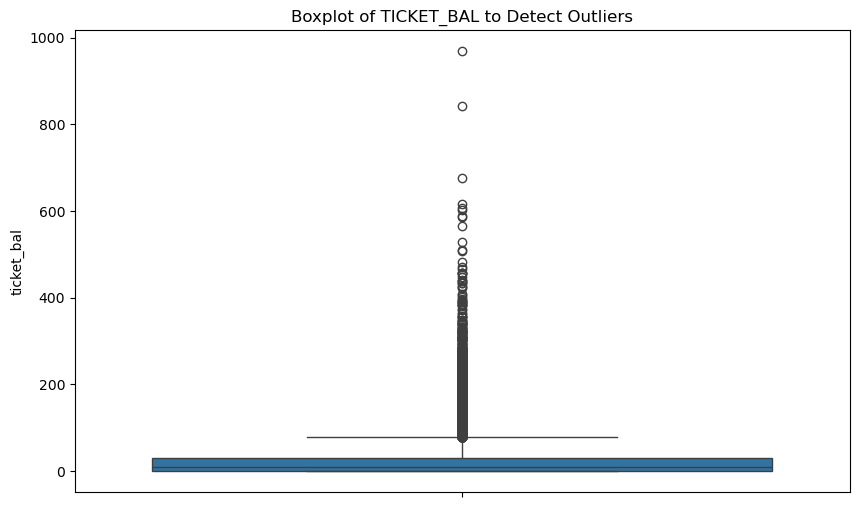

In [50]:
# Visualize TICKET_BAL distribution to detect anomalies
plt.figure(figsize=(10, 6))
sns.boxplot(data_reg["ticket_bal"])
plt.title("Boxplot of TICKET_BAL to Detect Outliers")
plt.show()

In [51]:
# run correlation analysis
data_reg.corr(numeric_only=True)['ticket_bal'].sort_values(ascending=False)

ticket_bal             1.00
conc_bal               0.41
concqtysum             0.40
life_spend_amt         0.34
life_award_amt         0.33
concloydisc            0.27
est_home_val_rng       0.18
unk_home               0.17
est_inc_rng            0.16
ol_fee_waive_amt       0.16
unk_inc                0.15
age21plus              0.06
age                    0.03
theatr_sms_offer      -0.00
reward_sms            -0.00
theatr_mob_offer      -0.03
reward_mobile         -0.03
age18to21             -0.04
age13to18             -0.06
reward_email          -0.08
loyalty_email_offer   -0.09
child_pres            -0.13
gendercode            -0.15
Name: ticket_bal, dtype: float64

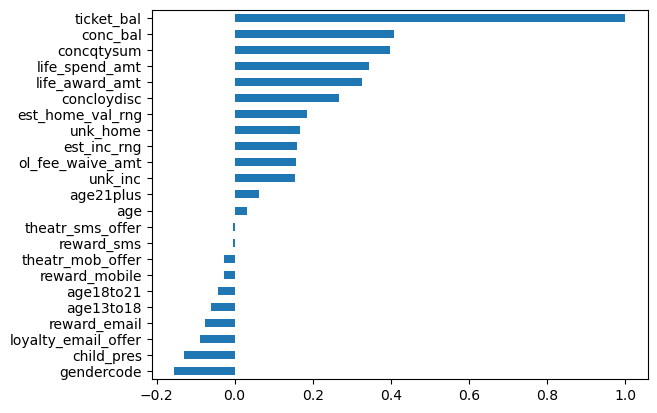

In [52]:
data_reg.corr(numeric_only=True)['ticket_bal'].sort_values(ascending=True).plot(kind='barh')
plt.show();

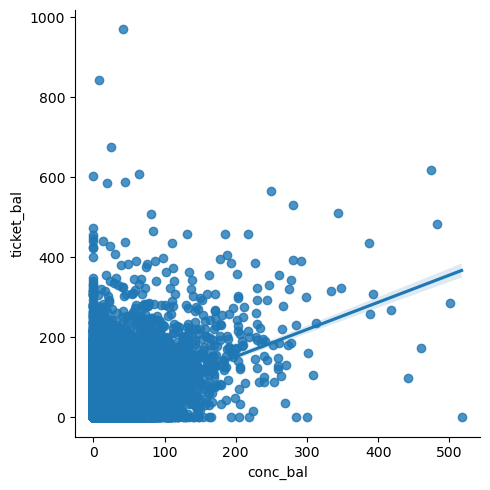

In [53]:
sns.lmplot(x='conc_bal', y='ticket_bal', data=data_reg)
plt.show();

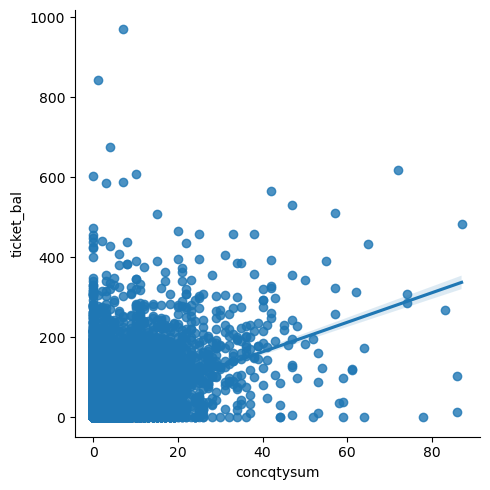

In [54]:
sns.lmplot(x='concqtysum', y='ticket_bal', data=data_reg)
plt.show();

## 3. Build Regression Models with TICKET_BAL as y value.

### a. Linear Regression

Linear Regression Without data processing.

In [55]:
cat_col = ['age21plus',
'loyalty_email_offer',
'theatr_mob_offer',
'theatr_sms_offer',
'reward_email',
'reward_mobile',
'child_pres',
'est_inc_rng',
'est_home_val_rng',
'reward_sms',
'gendercode',
'age13to18',
'age18to21',
'unk_inc',
'unk_home '
                        ]
num_cols = ['life_award_amt',
            'life_spend_amt',
            'ol_fee_waive_amt',
            'concqtysum',
            'concloydisc',
            'conc_bal',
            'age'
           ]

In [56]:
#assigning columns to X and Y variables

y = data_reg['ticket_bal']
X = data_reg.drop(['ticket_bal'], axis =1)  #a simple way to assign X variables (preferred)

In [57]:
# split validation (70% training & 30% testing data)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(32431, 22) (32431,) (13900, 22) (13900,)


In [58]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [59]:
from sklearn.metrics import mean_squared_error, r2_score
# Make predictions
y_pred_lr = lr.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r_squared_lr = r2_score(y_test, y_pred_lr)

In [60]:
# this is regression so it has coefficients and y-intercept
coefficients_lr = lr.coef_
intercept_lr = lr.intercept_

print("Coefficients:", coefficients_lr)
print("Intercept:", intercept_lr)

Coefficients: [-7.26 -10.06 -14.13 -3.99 -9.02 -2.49 -1.70 -25.45 -0.02 -25.45 -3.54
 0.40 0.10 -0.24 1.01 0.87 0.10 4.35 0.45 1.34 -7.43 -0.03]
Intercept: 39.634523507803635


Linear Regression with Data Processing ( Standardization)

In [61]:
# Initialize the StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [62]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Standardize the numerical features
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [63]:
# Convert the scaled numerical features back to a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [64]:
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [65]:
model_w_datapreprocessing = sm.OLS(y_train, X_train_sm).fit()

# Print the summary of the regression results
print(model_w_datapreprocessing.summary())

# Make predictions
y_pred_sm = model_w_datapreprocessing.predict(X_test_sm)

                            OLS Regression Results                            
Dep. Variable:             ticket_bal   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     700.1
Date:                Sun, 08 Dec 2024   Prob (F-statistic):               0.00
Time:                        18:11:12   Log-Likelihood:            -1.6007e+05
No. Observations:               32431   AIC:                         3.202e+05
Df Residuals:                   32409   BIC:                         3.204e+05
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  48.1781    

In [66]:
# Coefficients
coefficients_sm = model_w_datapreprocessing.params
print("\nCoefficients of the model:")
print(coefficients_sm)


Coefficients of the model:
const                   48.18
age21plus               -7.26
age18to21              -10.06
age13to18              -14.13
gendercode              -3.99
loyalty_email_offer     -9.02
reward_email            -2.49
reward_mobile           -1.70
reward_sms             -25.45
theatr_mob_offer        -0.02
theatr_sms_offer       -25.45
life_award_amt        -110.11
life_spend_amt         118.58
ol_fee_waive_amt         2.69
est_inc_rng             -0.24
est_home_val_rng         1.01
child_pres               0.87
concqtysum               0.44
concloydisc              4.47
conc_bal                10.97
unk_inc                  1.34
unk_home                -7.43
age                     -0.47
dtype: float64


Regularization with Lasso

In [67]:
from sklearn.linear_model import Lasso

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.1)  # You may need to tune the alpha parameter
lasso.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_test_scaled)

In [69]:
# Coefficients
coefficients_lasso = pd.Series(lasso.coef_, index=X.columns)
print("Lasso Coefficients:\n", coefficients_lasso)

Lasso Coefficients:
 age21plus               0.00
age18to21              -0.55
age13to18              -1.25
gendercode             -4.29
loyalty_email_offer    -3.63
reward_email           -0.81
reward_mobile          -0.64
reward_sms             -0.13
theatr_mob_offer       -0.08
theatr_sms_offer       -0.00
life_award_amt        -64.92
life_spend_amt         73.20
ol_fee_waive_amt        2.86
est_inc_rng            -0.01
est_home_val_rng        3.93
child_pres              0.64
concqtysum              0.46
concloydisc             4.35
conc_bal               11.36
unk_inc                -0.05
unk_home               -2.14
age                    -0.39
dtype: float64


Feature Selection

In [70]:
#selec only 5 X variables
from sklearn.feature_selection import f_regression
# Calculate the F-scores and p-values for the features
F_scores, p_values = f_regression(X, y)

# Create a DataFrame to store the F-scores and p-values
feature_scores = pd.DataFrame({'Feature': X.columns, 'F_Score': F_scores, 'P_Value': p_values})

# Select the top 5 features based on the F-score
top_features = feature_scores.nlargest(5, 'F_Score')['Feature']
print("Top 5 Features:\n", top_features)

Top 5 Features:
 18          conc_bal
16        concqtysum
11    life_spend_amt
10    life_award_amt
17       concloydisc
Name: Feature, dtype: object


In [71]:
# split validation (using X_new)
X_new = X[top_features]
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

In [72]:
# Model Building
from sklearn.linear_model import LinearRegression
X_train_new_scaled = scaler.fit_transform(X_train_new)
X_test_new_scaled = scaler.transform(X_test_new)

linear_model = LinearRegression()
linear_model.fit(X_train_new_scaled, y_train_new)

# Predictions
y_pred_new = linear_model.predict(X_test_new_scaled)

# Model Evaluation
mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print("Model with Selected Features Mean Squared Error:", mse_new)
print("Model with Selected Features R^2 Score:", r2_new)

Model with Selected Features Mean Squared Error: 1266.928003680327
Model with Selected Features R^2 Score: 0.22060268291307072


In [73]:
# Coefficients
new_coefficients = pd.Series(linear_model.coef_, index=top_features)
print("Linear Model Coefficients for Selected Features:\n", new_coefficients)

Linear Model Coefficients for Selected Features:
 Feature
conc_bal            9.82
concqtysum          1.01
life_spend_amt    124.73
life_award_amt   -115.53
concloydisc         4.50
dtype: float64


#### ii. Report the model accracy.

Model without Data Processing

In [74]:
# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r_squared_lr = r2_score(y_test, y_pred_lr)

# Print the evaluation metrics
print("\nModel Evaluation Metrics: Without Processing")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared: {r_squared_lr:.2f}")


Model Evaluation Metrics: Without Processing
Mean Squared Error (MSE): 1034.93
Root Mean Squared Error (RMSE): 32.17
R-squared: 0.29


Model with Data Processing

In [75]:
# Evaluate the model
mse_sm = np.mean((y_test - y_pred_sm) ** 2)
rmse_sm = np.sqrt(mse_sm)
r_squared_sm = model_w_datapreprocessing.rsquared  # R-squared from the statsmodels model

# Print the evaluation metrics
print("\nModel Evaluation Metrics: Standrdized")
print(f"Mean Squared Error (MSE): {mse_sm:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sm:.2f}")
print(f"R-squared: {r_squared_sm:.2f}")


Model Evaluation Metrics: Standrdized
Mean Squared Error (MSE): 1034.93
Root Mean Squared Error (RMSE): 32.17
R-squared: 0.31


Regularization with Lasso

In [76]:
# Evaluate the model
mse_lasso = np.mean((y_test - y_pred_lasso) ** 2)
rmse_lasso = np.sqrt(mse_lasso)

# Print the evaluation metrics
print("\nModel Evaluation Metrics: Lasso")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"R-squared: {r2_new:.2f}")


Model Evaluation Metrics: Lasso
Mean Squared Error (MSE): 1037.32
Root Mean Squared Error (RMSE): 32.21
R-squared: 0.22


#### ii. Visualize actual vs predicted

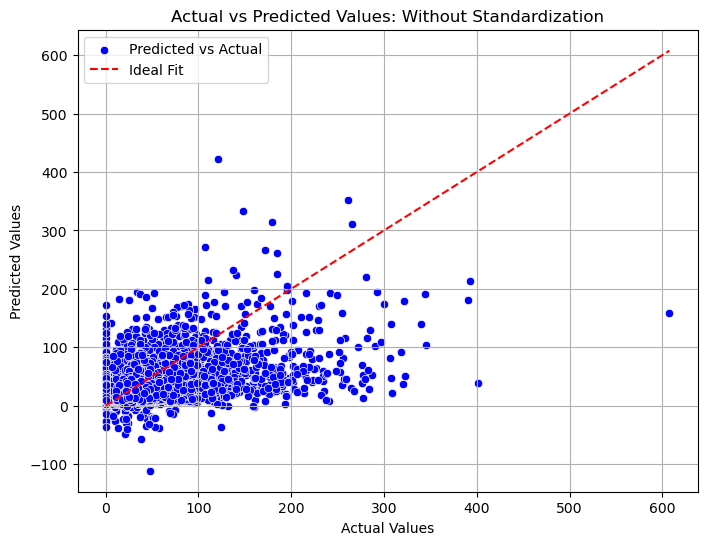

In [77]:
# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, color='blue', label='Predicted vs Actual')

# Line y=x for reference
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')

# Plot settings
plt.title('Actual vs Predicted Values: Without Standardization')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

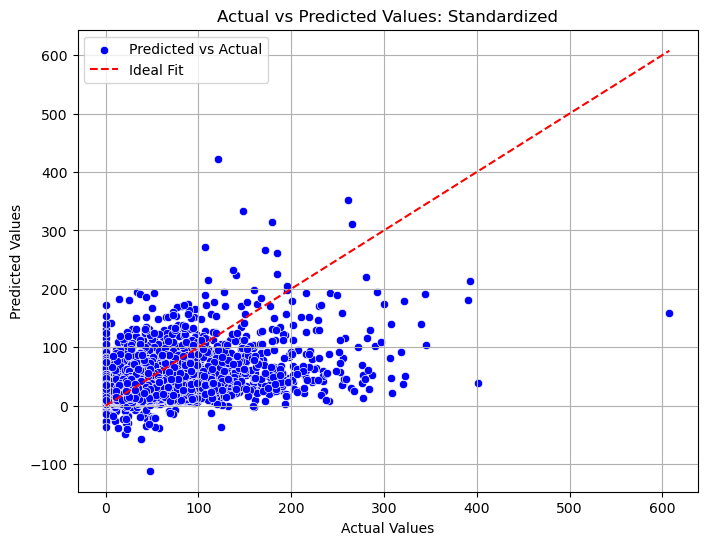

In [78]:
# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_sm, color='blue', label='Predicted vs Actual')

# Line y=x for reference
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')

# Plot settings
plt.title('Actual vs Predicted Values: Standardized')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

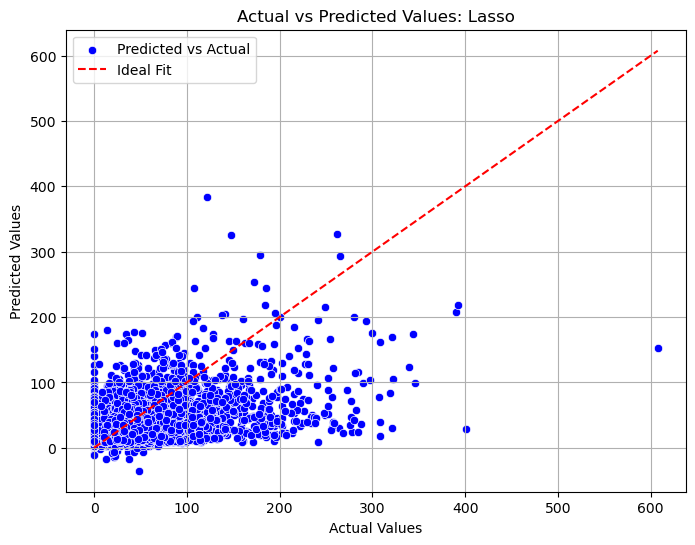

In [79]:
# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso, color='blue', label='Predicted vs Actual')

# Line y=x for reference
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')

# Plot settings
plt.title('Actual vs Predicted Values: Lasso')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

### b. Random forest Regressor

In [80]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor

In [81]:
# Define features (X) and target (y)
X = data_reg.drop(columns=["ticket_bal"])
y = data_reg["ticket_bal"]

In [82]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
# Initialize and train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [84]:
# Predict on the test set
y_pred = rf_reg.predict(X_test)

In [85]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
# Feature selection using Recursive Feature Elimination (RFE)
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rfe = RFE(estimator=rf_model, n_features_to_select=10)  # Select top 10 features
rfe.fit(X_train_scaled, y_train)

RFE(estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    n_features_to_select=10)

In [87]:
# Select the most important features
X_train_selected = X_train_scaled[:, rfe.support_]
X_test_selected = X_test_scaled[:, rfe.support_]
selected_features = X.columns[rfe.support_]

In [88]:
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['gendercode', 'life_award_amt', 'life_spend_amt', 'ol_fee_waive_amt',
       'est_inc_rng', 'est_home_val_rng', 'concqtysum', 'concloydisc',
       'conc_bal', 'age'],
      dtype='object')


In [89]:
# Train the Random Forest Regressor with selected features
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
rf_reg.fit(X_train_selected, y_train)

RandomForestRegressor(n_estimators=10, random_state=42)

#### i) Report the model accuracy

Before Standardization

In [90]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor Model:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"RMSE Value: {rmse:.2f}")
print(f"R-squared Value: {r2:.2f}")

Random Forest Regressor Model:
Mean Squared Error (MSE): 766.48
RMSE Value: 27.69
R-squared Value: 0.53


After Standardization

In [91]:
# Predict on the test set
y_pred_2 = rf_reg.predict(X_test_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_2)
r2 = r2_score(y_test, y_pred_2)

print("\nRandom Forest Regressor with Standardization and Feature Selection:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Value: {r2:.2f}")


Random Forest Regressor with Standardization and Feature Selection:
Mean Squared Error (MSE): 848.36
R-squared Value: 0.48


#### ii) Visualize actual vs predicted

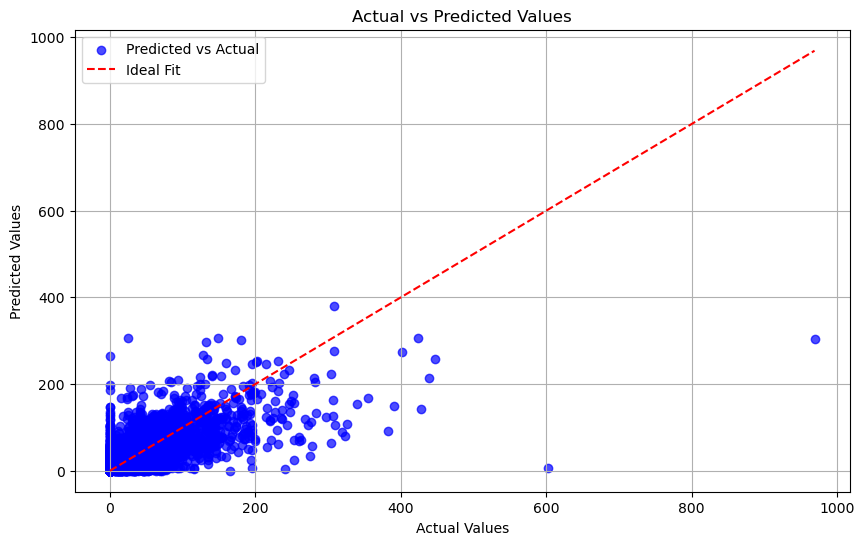

In [92]:
# Visualization: Actual vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Ideal Fit")
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid()
plt.show()

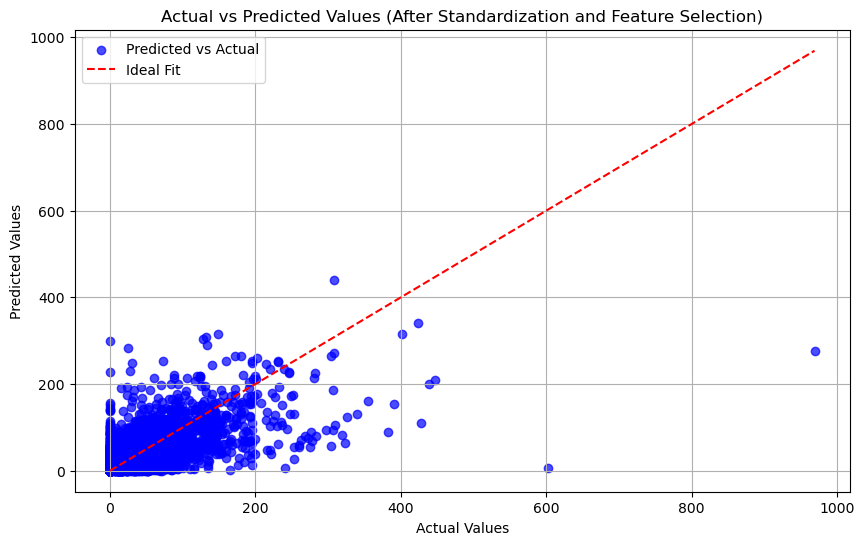

In [93]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_2, alpha=0.7, color='blue', label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Ideal Fit")
plt.title("Actual vs Predicted Values (After Standardization and Feature Selection)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid()
plt.show()


## 4. Best Model Evaluation

#### a. What is the accuracy?

In [94]:
# Compare models based on R-squared and MSE
print("Model Performance Comparison:")
print(f"Linear Regression - MSE: {mse_lr:.2f}, R-squared: {r_squared_lr:.2f}")
print(f"Random Forest Regressor - MSE: {mse:.2f}, R-squared: {r2:.2f}")

# Select the best model
best_model_name = "Random Forest Regressor" if r2 > r_squared_lr else "Linear Regression"
best_model_mse = min(mse_lr, mse)
best_model_r2 = max(r_squared_lr, r2)

print(f"Best Model: {best_model_name}")
print(f"Accuracy (R-squared): {best_model_r2:.2f}")
print(f"MSE: {best_model_mse:.2f}")


Model Performance Comparison:
Linear Regression - MSE: 1034.93, R-squared: 0.29
Random Forest Regressor - MSE: 848.36, R-squared: 0.48
Best Model: Random Forest Regressor
Accuracy (R-squared): 0.48
MSE: 848.36


#### b. Important Variables in Best Model

In [95]:
# Feature Importance from Random Forest
if best_model_name == "Random Forest Regressor":
    # Get the importance scores for the selected features (after RFE)
    feature_importances = pd.DataFrame({
        "Feature": selected_features,  # Use selected features from RFE
        "Importance": rf_reg.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("Important Variables for Predicting TICKET_BAL:")
    print(feature_importances)


Important Variables for Predicting TICKET_BAL:
            Feature  Importance
2    life_spend_amt        0.49
8          conc_bal        0.12
3  ol_fee_waive_amt        0.11
9               age        0.08
7       concloydisc        0.05
6        concqtysum        0.04
5  est_home_val_rng        0.03
1    life_award_amt        0.03
4       est_inc_rng        0.02
0        gendercode        0.02


# PART III: Clustering

## 1. K-Means Clustering

### a. Use the Elbow Method to Determine Optimal 𝐾

In [96]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

# Select relevant features for clustering (excluding non-numeric and target columns)
clustering_data = data_reg.drop(columns=["ticket_bal"], errors="ignore")

# Standardize the data
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

# Elbow method to find optimal K
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(clustering_data_scaled)
    inertia.append(kmeans.inertia_)

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


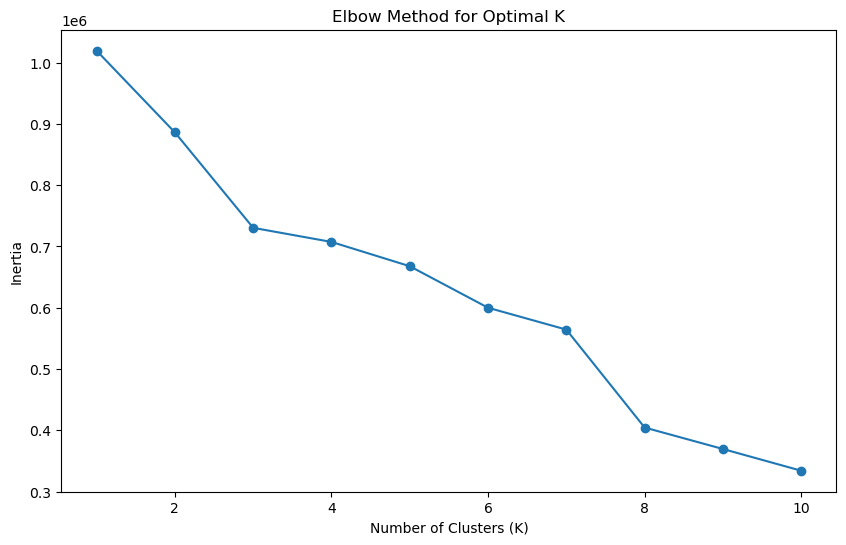

In [97]:
# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

### b. Use 𝐾=3 for Clustering

In [98]:
# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(clustering_data_scaled)

# Add cluster labels to the original dataset
data_with_clusters = data_reg.copy()
data_with_clusters["Cluster"] = clusters

# Inspect cluster counts
print(data_with_clusters["Cluster"].value_counts())

Cluster
0    21064
1    17211
2     8056
Name: count, dtype: int64


## 2. Cluster Profiles

### a. Build a Simple Decision Tree Using Clustering Results

In [99]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Prepare data for decision tree
X_clf = clustering_data_scaled
y_clf = clusters

# Train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Train Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)  # Limiting depth for simplicity
dt_clf.fit(X_train_clf, y_train_clf)

DecisionTreeClassifier(max_depth=3, random_state=42)

#### i. Visualize the decision tree or print decision rules

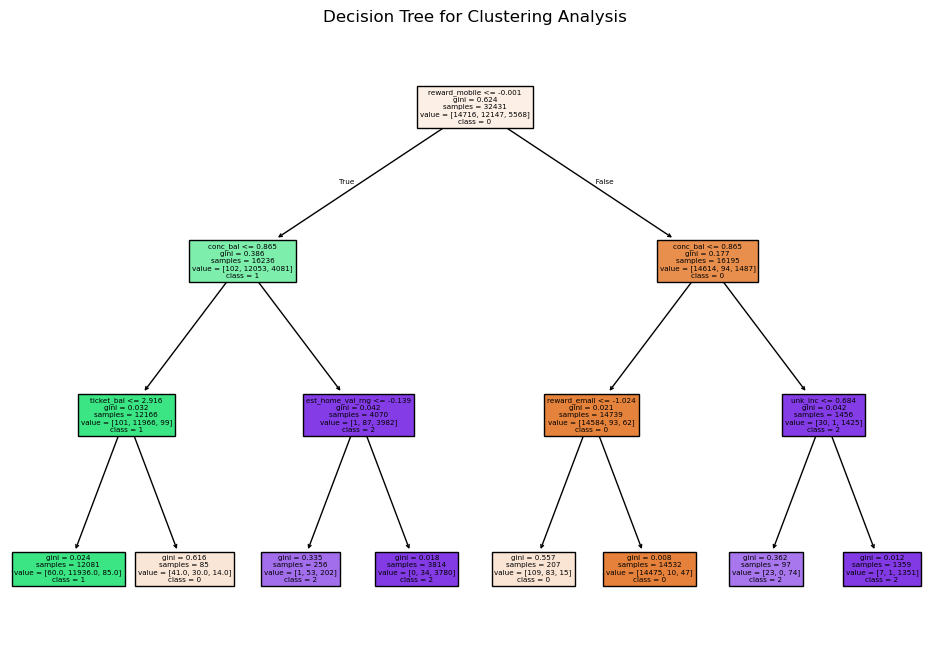

In [100]:
# Visualize the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(dt_clf, feature_names=data_reg.columns, class_names=[str(i) for i in np.unique(y_clf)], filled=True)
plt.title("Decision Tree for Clustering Analysis")
plt.show();

1. If `reward_mobile` is less than or equal to 0, and `unk_inc` is less than or equal to 0.87, and `concqtysum` is less than or equal to 2.92, then the predicted class is 1.
2. If `reward_mobile` is less than or equal to 0, and `unk_inc` is greater than 0.87, and `est_home_val_rng` is less than or equal to -0.14, then the predicted class is 2.
3. If `reward_mobile` is greater than 0, and `unk_inc` is less than or equal to 0.87, and `reward_email` is greater than -1.02, then the predicted class is 0.

In [101]:
from sklearn.tree import export_text

# Get feature names (exclude the target variable 'TICKET_BAL')
feature_names = list(data_reg.drop(columns=["ticket_bal"]).columns)

# Print Decision Rules
decision_rules = export_text(dt_clf, feature_names=feature_names)
print("Decision Rules from the Decision Tree:")
print(decision_rules)

Decision Rules from the Decision Tree:
|--- reward_mobile <= -0.00
|   |--- unk_inc <= 0.87
|   |   |--- concqtysum <= 2.92
|   |   |   |--- class: 1
|   |   |--- concqtysum >  2.92
|   |   |   |--- class: 0
|   |--- unk_inc >  0.87
|   |   |--- est_home_val_rng <= -0.14
|   |   |   |--- class: 2
|   |   |--- est_home_val_rng >  -0.14
|   |   |   |--- class: 2
|--- reward_mobile >  -0.00
|   |--- unk_inc <= 0.87
|   |   |--- reward_email <= -1.02
|   |   |   |--- class: 0
|   |   |--- reward_email >  -1.02
|   |   |   |--- class: 0
|   |--- unk_inc >  0.87
|   |   |--- unk_home <= 0.68
|   |   |   |--- class: 2
|   |   |--- unk_home >  0.68
|   |   |   |--- class: 2



1. If `reward_mobile` is less than or equal to 0, `unk_inc` is greater than 0.87, and `est_home_val_rng` is greater than -0.14, then the predicted class is 2.

2. If `reward_mobile` is greater than 0, `unk_inc` is less than or equal to 0.87, and `reward_email` is less than or equal to -1.02, then the predicted class is 0.

3. If `reward_mobile` is greater than 0, `unk_inc` is greater than 0.87, and `unk_home` is less than or equal to 0.68, then the predicted class is 2.

#### ii. Report the model accuracy.


In [102]:
# Predictions and Accuracy
y_pred_clf = dt_clf.predict(X_test_clf)
accuracy_dt = accuracy_score(y_test_clf, y_pred_clf)

print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")

Decision Tree Accuracy: 0.99


### b. Develop Customer Profiles

In [103]:
# Group by clusters and calculate mean values for each feature
cluster_profiles = data_with_clusters.groupby("Cluster").mean()

# Add cluster size to profiles
cluster_profiles["Cluster Size"] = data_with_clusters["Cluster"].value_counts()

print("Customer Profiles Based on Clustering:")
cluster_profiles

Customer Profiles Based on Clustering:


,age21plus,age18to21,age13to18,gendercode,loyalty_email_offer,reward_email,reward_mobile,reward_sms,theatr_mob_offer,theatr_sms_offer,...,est_home_val_rng,child_pres,ticket_bal,concqtysum,concloydisc,conc_bal,unk_inc,unk_home,age,Cluster Size
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.88,0.07,0.05,2.84,0.99,0.99,0.99,0.00,1.00,0.00,...,0.22,3.00,18.00,2.63,0.19,15.17,0.00,0.02,46.39,21064
1,0.89,0.07,0.04,2.24,0.62,0.71,0.01,0.00,0.01,0.00,...,0.93,2.99,22.74,0.67,0.09,3.85,0.01,0.11,43.88,17211
2,0.94,0.04,0.01,1.90,0.77,0.81,0.27,0.00,0.28,0.00,...,9.80,1.16,38.53,3.22,0.45,18.41,0.97,0.96,49.63,8056


In [104]:
# Provide interpretations
for cluster in cluster_profiles.index:
    print(f"\nCluster {cluster} Characteristics:")
    print(cluster_profiles.loc[cluster].drop("Cluster Size"))


Cluster 0 Characteristics:
age21plus              0.88
age18to21              0.07
age13to18              0.05
gendercode             2.84
loyalty_email_offer    0.99
reward_email           0.99
reward_mobile          0.99
reward_sms             0.00
theatr_mob_offer       1.00
theatr_sms_offer       0.00
life_award_amt         0.86
life_spend_amt        13.56
ol_fee_waive_amt       0.34
est_inc_rng            0.01
est_home_val_rng       0.22
child_pres             3.00
ticket_bal            18.00
concqtysum             2.63
concloydisc            0.19
conc_bal              15.17
unk_inc                0.00
unk_home               0.02
age                   46.39
Name: 0, dtype: float64

Cluster 1 Characteristics:
age21plus              0.89
age18to21              0.07
age13to18              0.04
gendercode             2.24
loyalty_email_offer    0.62
reward_email           0.71
reward_mobile          0.01
reward_sms             0.00
theatr_mob_offer       0.01
theatr_sms_offer       0

# Part IV:StoryTelling

## Who are the customers that are likely to convert to Premier?

Based on the data analysis, we can infer the profile of customers most likely to convert to Premier. These are individuals who are generally **younger** and show **higher spending habits**, indicating a readiness to invest in a more premium service. Customers in the **mid-wealth** and **higher-wealth categories** with **consistent usage patterns** are more inclined to transition to Premier. Additionally, those who have had **positive interactions with customer support** or have been with the service for **longer durations** show a greater likelihood of upgrading to Premier.

**Key Characteristics:**
- **Age Range**: Younger customers (typically between 25-40 years old) are more likely to upgrade.
- **Spending Habits**: Those who already make substantial purchases or have higher annual spending are good candidates.
- **Wealth Categories**: Customers in the **mid-wealth** and **upper-wealth** segments are more inclined to move to Premier.
- **Interaction with Support**: Customers with a higher frequency of positive support interactions tend to upgrade.
- **Loyalty**: Long-term users show a greater likelihood of converting to Premier, especially if they have been using the service consistently for several years.


## Who are the customers that utilize Premier?

Premier customers are typically **high-value clients** who have already demonstrated a strong preference for **premium services**. They tend to be **older customers** who have been with the brand for a longer period, which indicates loyalty. These customers are also characterized by **higher income levels**, making them more willing to pay for premium services. Moreover, they are likely to **frequently engage with the service**, indicating that they derive substantial value from it. Additionally, Premier users tend to have **higher usage frequency** and a **larger number of transactions**, further justifying their preference for a premium experience.

**Key Characteristics:**
- **Age Range**: Older customers, typically above 35 years, are frequent users of Premier.
- **Income Levels**: Higher income customers are more likely to pay for premium services.
- **Engagement Levels**: High-frequency users and those with many transactions are more inclined to choose Premier.
- **Loyalty**: Long-standing customers with positive engagement history are strong users of Premier.

## Who are the customers that utilize Insider?

Insider customers tend to be **younger individuals** who are still exploring the brand and **test-driving services** before committing to higher-tier options like Premier. These customers often belong to the **lower-wealth** or **mid-wealth** segments and may be **more price-sensitive**. They exhibit less frequency in their purchases compared to Premier users, often engaging with **basic or entry-level features**. They may also be looking for specific services or **discounts**, indicating they are cost-conscious but still interested in premium experiences. **Frequent trial users** or customers who have a **shorter history** with the brand are more likely to be in this category.

**Key Characteristics:**
- **Age Range**: Younger individuals, often between 20-30 years old, are common users of Insider.
- **Wealth Segments**: Primarily low to mid-wealth customers who may be more price-conscious.
- **Usage Frequency**: Occasional users or those engaging in **trial experiences** are typical.
- **Engagement with Discounts**: Customers who show interest in **discounts** and **special offers**.
- **Loyalty**: Newer or less engaged customers who are exploring the brand for the first time.